# N2 - Extração e análise de tarefas administrativas em SQLite

**Disciplina:** Práticas em Engenharia de Produção  
**Tema:** Aplicação prática do Procedimento Operacional Padrão (POP) 
**Tecnologias:** SQLite, Python, pandas, SQL e matplotlib  
**Base utilizada:** banco relacional modificado 

## Objetivo

Aplicar o POP proposto na N1 para conectar-se a um banco SQLite, explorar sua estrutura,
extrair dados por consultas SQL, calcular indicadores administrativos, interpretar os
resultados e propor ações de melhoria.

## Pergunta gerencial

**Como a distribuição das tarefas, o backlog, os atrasos, o tempo de execução, a
produtividade e o retrabalho ajudam a identificar possíveis gargalos nos processos
administrativos?**

## Recorte temporal

A análise principal considera o período de **01/01/2026 a 31/03/2026**. O campo
`data_abertura` é utilizado para o volume de novas tarefas. Indicadores de conclusão
utilizam `data_conclusao`. O backlog representa uma fotografia das pendências em
**31/03/2026**.

> Nota: A estrutura dos dados utilizados é real, no entanto, foram feitas 
> modificações dos valores e dos nomes dos funcionários, com o objetivo de 
> preservar a confidencialidade dos dados da empresa e respeitar a LGPD. 
> Portanto, as interpretações demonstram o método analítico, mas são baseadas
> apenas nos dados modificados, e não nos dados reais.


## 1. Preparação do ambiente

Esta etapa importa as bibliotecas, define o período analisado e prepara a pasta em que
as tabelas e os gráficos serão gravados.


In [1]:
from pathlib import Path
import platform
import sqlite3
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

CORES = {
    "azul": "#2457A7",
    "azul_claro": "#73A5E3",
    "laranja": "#E67E22",
    "vermelho": "#C0392B",
    "verde": "#2E8B57",
    "cinza": "#5B6573",
}

DATA_INICIO = "2026-01-01"
DATA_FIM = "2026-03-31"
PARAMETROS_PERIODO = {
    "data_inicio": DATA_INICIO,
    "data_fim": DATA_FIM,
}

PASTA_RESULTADOS = Path.cwd() / "resultados_n2"
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

print(f"Python: {sys.version.split()[0]}")
print(f"Sistema: {platform.system()} {platform.release()}")
print(f"Período: {DATA_INICIO} a {DATA_FIM}")
print(f"Resultados: {PASTA_RESULTADOS.resolve()}")


Python: 3.13.6
Sistema: Windows 11
Período: 2026-01-01 a 2026-03-31
Resultados: C:\Users\gusta\OneDrive\Área de Trabalho\Práticas em Eng Prod\resultados_n2


## 2. Localização e conexão com o banco SQLite

O SQLite armazena o banco em um único arquivo. O código procura o arquivo na pasta do
notebook e, como alternativa, na pasta `Downloads`. 


In [2]:
NOME_BANCO = "tarefas_administrativas_n2.sqlite"

caminhos_possiveis = [
    Path.cwd() / NOME_BANCO,
    Path.cwd().parent / NOME_BANCO,
    Path.home() / "Downloads" / NOME_BANCO,
]

CAMINHO_BANCO = next(
    (caminho for caminho in caminhos_possiveis if caminho.exists()),
    None,
)

if CAMINHO_BANCO is None:
    caminhos_testados = "\n".join(f"- {caminho}" for caminho in caminhos_possiveis)
    raise FileNotFoundError(
        f"O banco {NOME_BANCO!r} não foi encontrado.\n"
        f"Caminhos testados:\n{caminhos_testados}"
    )

conexao = sqlite3.connect(CAMINHO_BANCO)
conexao.execute("PRAGMA foreign_keys = ON")

def consultar(sql, parametros=None):
    """Executa uma consulta SQL e devolve o resultado como DataFrame."""
    return pd.read_sql_query(sql, conexao, params=parametros or {})

def salvar_tabela(dataframe, nome_arquivo):
    """Salva um DataFrame em CSV usando codificação compatível com Excel."""
    caminho = PASTA_RESULTADOS / nome_arquivo
    dataframe.to_csv(caminho, index=False, encoding="utf-8-sig")
    return caminho

def salvar_grafico(nome_arquivo):
    """Finaliza, grava e exibe o gráfico atual."""
    caminho = PASTA_RESULTADOS / nome_arquivo
    plt.tight_layout()
    plt.savefig(caminho, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
    return caminho

teste_conexao = consultar(
    """
    SELECT
        sqlite_version() AS versao_sqlite,
        datetime('now', 'localtime') AS data_hora_teste
    """
)

print("Conexão realizada com sucesso.")
print(f"Banco: {CAMINHO_BANCO.resolve()}")
display(teste_conexao)


Conexão realizada com sucesso.
Banco: C:\Users\gusta\OneDrive\Área de Trabalho\Práticas em Eng Prod\tarefas_administrativas_n2.sqlite


,versao_sqlite,data_hora_teste
0,3.49.1,2026-06-22 18:11:01


## 3. Exploração da estrutura relacional

Nesta etapa são identificadas as tabelas, suas quantidades de registros, colunas,
chaves primárias e chaves estrangeiras. A exploração evidencia a normalização e os
relacionamentos utilizados posteriormente nos `JOINs`.


In [3]:
tabelas = consultar(
    """
    SELECT name AS tabela
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
    """
)

resumo_tabelas = []
detalhes_colunas = []
detalhes_chaves = []

for nome_tabela in tabelas["tabela"]:
    nome_seguro = nome_tabela.replace('"', '""')
    quantidade = consultar(
        f'SELECT COUNT(*) AS quantidade FROM "{nome_seguro}"'
    ).loc[0, "quantidade"]

    resumo_tabelas.append(
        {"tabela": nome_tabela, "quantidade_registros": int(quantidade)}
    )

    colunas = consultar(f'PRAGMA table_info("{nome_seguro}")')
    colunas.insert(0, "tabela", nome_tabela)
    detalhes_colunas.append(colunas)

    chaves = consultar(f'PRAGMA foreign_key_list("{nome_seguro}")')
    if not chaves.empty:
        chaves.insert(0, "tabela_origem", nome_tabela)
        detalhes_chaves.append(chaves)

df_resumo_tabelas = pd.DataFrame(resumo_tabelas).sort_values("tabela")
df_colunas = pd.concat(detalhes_colunas, ignore_index=True)
df_chaves = pd.concat(detalhes_chaves, ignore_index=True)

display(Markdown("### Tabelas e quantidade de registros"))
display(df_resumo_tabelas)

display(Markdown("### Dicionário de campos"))
display(
    df_colunas[
        ["tabela", "name", "type", "notnull", "dflt_value", "pk"]
    ].rename(
        columns={
            "name": "campo",
            "type": "tipo",
            "notnull": "obrigatorio",
            "dflt_value": "valor_padrao",
            "pk": "chave_primaria",
        }
    )
)

display(Markdown("### Relacionamentos por chaves estrangeiras"))
display(
    df_chaves[
        ["tabela_origem", "from", "table", "to"]
    ].rename(
        columns={
            "from": "campo_origem",
            "table": "tabela_destino",
            "to": "campo_destino",
        }
    )
)

salvar_tabela(df_resumo_tabelas, "01_resumo_tabelas.csv")


### Tabelas e quantidade de registros

,tabela,quantidade_registros
0,atividades,72
1,funcionarios,60
2,historico_tarefas,2535
3,prioridades,4
4,processos,24
5,setores,8
6,status_tarefa,5
7,tarefas,1450


### Dicionário de campos

,tabela,campo,tipo,obrigatorio,valor_padrao,chave_primaria
0,atividades,id_atividade,INTEGER,0,None,1
1,atividades,id_processo,INTEGER,1,None,0
2,atividades,nome_atividade,TEXT,1,None,0
3,atividades,descricao_atividade,TEXT,0,None,0
4,atividades,tempo_padrao_estimado,REAL,1,None,0
5,funcionarios,id_funcionario,INTEGER,0,None,1
6,funcionarios,nome_funcionario,TEXT,1,None,0
7,funcionarios,cargo,TEXT,1,None,0
8,funcionarios,id_setor,INTEGER,1,None,0
9,funcionarios,data_admissao,TEXT,1,None,0


### Relacionamentos por chaves estrangeiras

,tabela_origem,campo_origem,tabela_destino,campo_destino
0,atividades,id_processo,processos,id_processo
1,funcionarios,id_setor,setores,id_setor
2,historico_tarefas,id_funcionario_alteracao,funcionarios,id_funcionario
3,historico_tarefas,id_tarefa,tarefas,id_tarefa
4,processos,id_setor,setores,id_setor
5,tarefas,id_prioridade,prioridades,id_prioridade
6,tarefas,id_status,status_tarefa,id_status
7,tarefas,id_responsavel,funcionarios,id_funcionario
8,tarefas,id_atividade,atividades,id_atividade


WindowsPath('c:/Users/gusta/OneDrive/Área de Trabalho/Práticas em Eng Prod/resultados_n2/01_resumo_tabelas.csv')

### 3.1. Diagrama simplificado do modelo de dados

O diagrama abaixo mostra a cadeia principal:

`setores → funcionários → tarefas ← atividades ← processos`

As tabelas `status_tarefa` e `prioridades` classificam as tarefas, enquanto
`historico_tarefas` registra alterações realizadas ao longo do tempo.


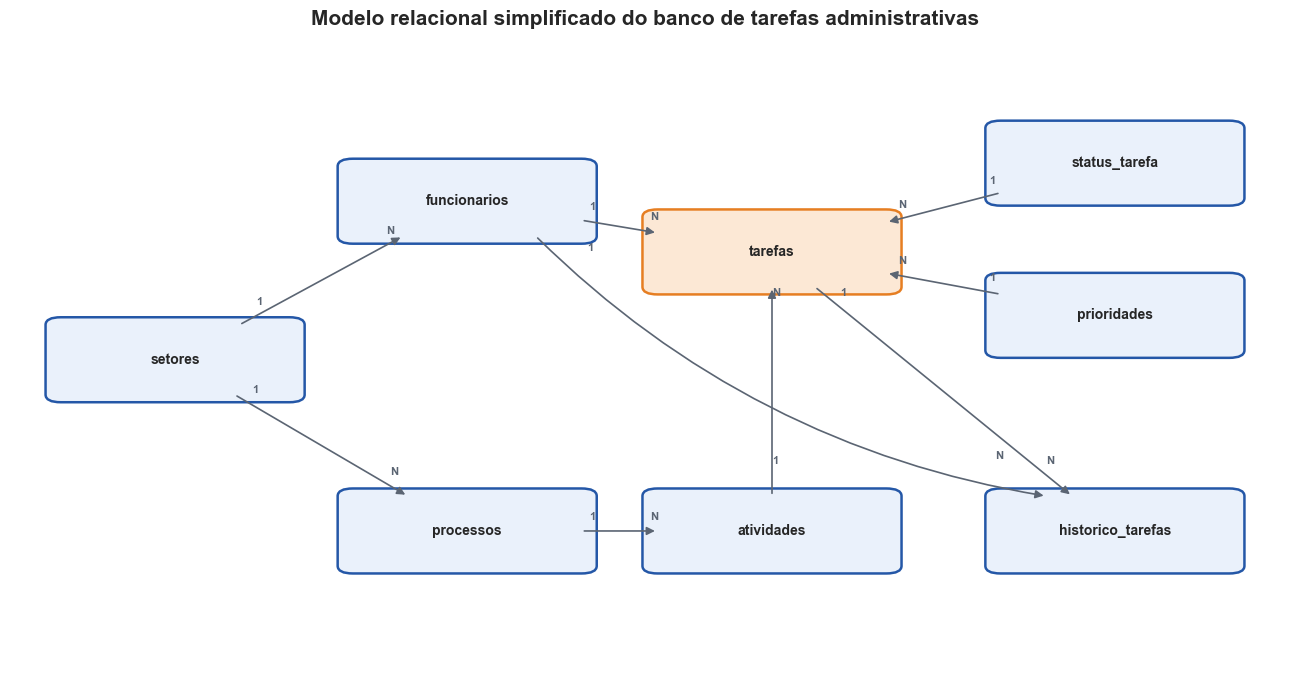

WindowsPath('c:/Users/gusta/OneDrive/Área de Trabalho/Práticas em Eng Prod/resultados_n2/02_modelo_relacional.png')

In [4]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

posicoes = {
    "setores": (0.04, 0.45),
    "funcionarios": (0.27, 0.70),
    "processos": (0.27, 0.18),
    "atividades": (0.51, 0.18),
    "tarefas": (0.51, 0.62),
    "status_tarefa": (0.78, 0.76),
    "prioridades": (0.78, 0.52),
    "historico_tarefas": (0.78, 0.18),
}

# Cada tupla representa: tabela "1", tabela "N", curvatura da ligação.
relacionamentos = [
    ("setores", "funcionarios", 0.00),
    ("setores", "processos", 0.00),
    ("processos", "atividades", 0.00),
    ("funcionarios", "tarefas", 0.00),
    ("atividades", "tarefas", 0.00),
    ("status_tarefa", "tarefas", 0.00),
    ("prioridades", "tarefas", 0.00),
    ("tarefas", "historico_tarefas", 0.00),
    ("funcionarios", "historico_tarefas", 0.16),
]

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

largura, altura = 0.18, 0.11

for tabela, (x, y) in posicoes.items():
    caixa = FancyBboxPatch(
        (x, y),
        largura,
        altura,
        boxstyle="round,pad=0.012",
        facecolor="#EAF1FB" if tabela != "tarefas" else "#FCE8D5",
        edgecolor=CORES["azul"] if tabela != "tarefas" else CORES["laranja"],
        linewidth=1.8,
    )
    ax.add_patch(caixa)
    ax.text(
        x + largura / 2,
        y + altura / 2,
        tabela,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

def ponto_na_borda(tabela_origem, tabela_destino):
    """Calcula o ponto em que a ligação deixa a borda de uma caixa."""
    x1, y1 = posicoes[tabela_origem]
    x2, y2 = posicoes[tabela_destino]
    centro_1 = (x1 + largura / 2, y1 + altura / 2)
    centro_2 = (x2 + largura / 2, y2 + altura / 2)
    dx = centro_2[0] - centro_1[0]
    dy = centro_2[1] - centro_1[1]

    limites = []
    if dx != 0:
        limites.append((largura / 2) / abs(dx))
    if dy != 0:
        limites.append((altura / 2) / abs(dy))

    fator = min(limites)
    return (
        centro_1[0] + dx * fator,
        centro_1[1] + dy * fator,
    )

for origem, destino, curvatura in relacionamentos:
    inicio = ponto_na_borda(origem, destino)
    fim = ponto_na_borda(destino, origem)
    seta = FancyArrowPatch(
        inicio,
        fim,
        arrowstyle="-|>",
        mutation_scale=12,
        color=CORES["cinza"],
        linewidth=1.2,
        connectionstyle=f"arc3,rad={curvatura}",
    )
    ax.add_patch(seta)

    # Cardinalidade: uma ocorrência na origem pode estar ligada a várias no destino.
    deslocamento_x = fim[0] - inicio[0]
    deslocamento_y = fim[1] - inicio[1]
    ax.text(
        inicio[0] + 0.10 * deslocamento_x,
        inicio[1] + 0.10 * deslocamento_y + 0.018,
        "1",
        fontsize=8,
        color=CORES["cinza"],
        fontweight="bold",
    )
    ax.text(
        inicio[0] + 0.90 * deslocamento_x,
        inicio[1] + 0.90 * deslocamento_y + 0.018,
        "N",
        fontsize=8,
        color=CORES["cinza"],
        fontweight="bold",
    )

ax.set_title(
    "Modelo relacional simplificado do banco de tarefas administrativas",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
salvar_grafico("02_modelo_relacional.png")


## 4. Validação da integridade e da qualidade dos dados

Valores nulos em `data_inicio` e `data_conclusao` não são automaticamente erros:
tarefas abertas podem ainda não ter sido iniciadas ou concluídas. Por isso, a análise
verifica tanto a quantidade de nulos quanto sua coerência com o status da tarefa.


In [5]:
integridade = consultar("PRAGMA integrity_check")
inconsistencias_fk = consultar("PRAGMA foreign_key_check")

qualidade = consultar(
    """
    SELECT
        COUNT(*) AS total_tarefas,
        SUM(CASE WHEN data_inicio IS NULL THEN 1 ELSE 0 END) AS inicio_nulo,
        SUM(CASE WHEN data_conclusao IS NULL THEN 1 ELSE 0 END) AS conclusao_nula,
        SUM(
            CASE
                WHEN data_inicio IS NOT NULL
                 AND date(data_inicio) < date(data_abertura)
                THEN 1 ELSE 0
            END
        ) AS inicio_antes_abertura,
        SUM(
            CASE
                WHEN data_conclusao IS NOT NULL
                 AND date(data_conclusao) < date(data_inicio)
                THEN 1 ELSE 0
            END
        ) AS conclusao_antes_inicio,
        SUM(
            CASE
                WHEN date(data_prazo) < date(data_abertura)
                THEN 1 ELSE 0
            END
        ) AS prazo_antes_abertura
    FROM tarefas
    """
)

nulos_por_status = consultar(
    """
    SELECT
        st.nome_status,
        COUNT(*) AS total,
        SUM(CASE WHEN t.data_inicio IS NULL THEN 1 ELSE 0 END) AS inicio_nulo,
        SUM(CASE WHEN t.data_conclusao IS NULL THEN 1 ELSE 0 END) AS conclusao_nula
    FROM tarefas t
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    GROUP BY st.nome_status
    ORDER BY total DESC
    """
)

intervalo_datas = consultar(
    """
    SELECT
        MIN(data_abertura) AS primeira_abertura,
        MAX(data_abertura) AS ultima_abertura,
        MIN(data_conclusao) AS primeira_conclusao,
        MAX(data_conclusao) AS ultima_conclusao
    FROM tarefas
    """
)

display(Markdown("### Verificação do arquivo e das chaves estrangeiras"))
display(integridade)
print(f"Inconsistências de chave estrangeira: {len(inconsistencias_fk)}")

display(Markdown("### Verificações de datas e valores nulos"))
display(qualidade)
display(nulos_por_status)

display(Markdown("### Intervalo temporal disponível"))
display(intervalo_datas)

if integridade.iloc[0, 0] == "ok" and inconsistencias_fk.empty:
    print("Resultado: o arquivo está íntegro e não há violações de chaves estrangeiras.")


### Verificação do arquivo e das chaves estrangeiras

,integrity_check
0,ok


Inconsistências de chave estrangeira: 0


### Verificações de datas e valores nulos

,total_tarefas,inicio_nulo,conclusao_nula,inicio_antes_abertura,conclusao_antes_inicio,prazo_antes_abertura
0,1450,141,513,0,0,0


,nome_status,total,inicio_nulo,conclusao_nula
0,Concluída,875,0,0
1,Em andamento,249,0,249
2,Aberta,141,141,141
3,Aguardando validação,123,0,123
4,Cancelada,62,0,0


### Intervalo temporal disponível

,primeira_abertura,ultima_abertura,primeira_conclusao,ultima_conclusao
0,2025-01-01,2026-03-31,2025-01-04,2026-04-12


Resultado: o arquivo está íntegro e não há violações de chaves estrangeiras.


## 5. Exploração inicial do conteúdo

A distribuição por status e prioridade permite compreender o perfil geral da base antes
da criação dos indicadores consolidados.


,nome_status,quantidade,percentual
0,Concluída,875,60.34
1,Em andamento,249,17.17
2,Aberta,141,9.72
3,Aguardando validação,123,8.48
4,Cancelada,62,4.28


,nome_prioridade,peso_prioridade,quantidade,percentual
0,Crítica,4,103,7.10
1,Alta,3,332,22.90
2,Média,2,643,44.34
3,Baixa,1,372,25.66


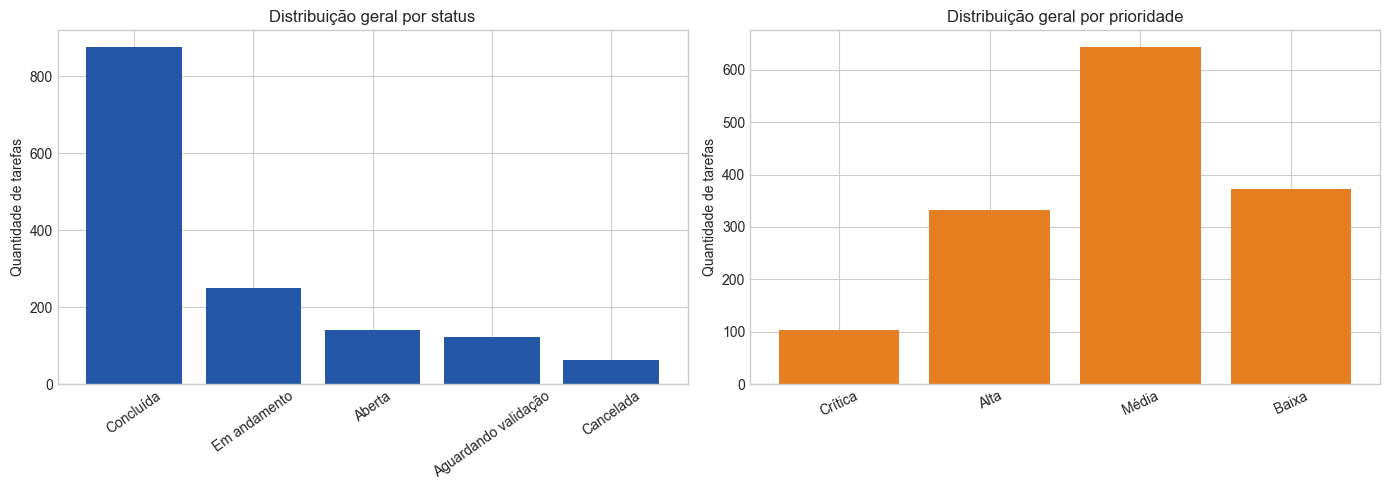

WindowsPath('c:/Users/gusta/OneDrive/Área de Trabalho/Práticas em Eng Prod/resultados_n2/03_distribuicoes_status_prioridade.png')

In [6]:
distribuicao_status = consultar(
    """
    SELECT
        st.nome_status,
        COUNT(*) AS quantidade,
        ROUND(
            100.0 * COUNT(*) / (SELECT COUNT(*) FROM tarefas),
            2
        ) AS percentual
    FROM tarefas t
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    GROUP BY st.nome_status
    ORDER BY quantidade DESC
    """
)

distribuicao_prioridade = consultar(
    """
    SELECT
        p.nome_prioridade,
        p.peso_prioridade,
        COUNT(*) AS quantidade,
        ROUND(
            100.0 * COUNT(*) / (SELECT COUNT(*) FROM tarefas),
            2
        ) AS percentual
    FROM tarefas t
    JOIN prioridades p
      ON p.id_prioridade = t.id_prioridade
    GROUP BY p.id_prioridade, p.nome_prioridade, p.peso_prioridade
    ORDER BY p.peso_prioridade DESC
    """
)

display(distribuicao_status)
display(distribuicao_prioridade)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].bar(
    distribuicao_status["nome_status"],
    distribuicao_status["quantidade"],
    color=CORES["azul"],
)
eixos[0].set_title("Distribuição geral por status")
eixos[0].set_ylabel("Quantidade de tarefas")
eixos[0].tick_params(axis="x", rotation=35)

eixos[1].bar(
    distribuicao_prioridade["nome_prioridade"],
    distribuicao_prioridade["quantidade"],
    color=CORES["laranja"],
)
eixos[1].set_title("Distribuição geral por prioridade")
eixos[1].set_ylabel("Quantidade de tarefas")
eixos[1].tick_params(axis="x", rotation=25)

salvar_grafico("03_distribuicoes_status_prioridade.png")


## 6. Extração da base analítica do período

A consulta usa múltiplos `JOINs` para transformar códigos armazenados nas chaves
estrangeiras em informações legíveis. A tabela resultante é a base detalhada das
tarefas abertas no trimestre.


In [7]:
query_base_analitica = """
    SELECT
        t.id_tarefa,
        t.data_abertura,
        t.data_inicio,
        t.data_prazo,
        t.data_conclusao,
        t.retrabalho,
        st.nome_status,
        prio.nome_prioridade,
        prio.peso_prioridade,
        f.id_funcionario,
        f.nome_funcionario,
        f.cargo,
        s.id_setor,
        s.nome_setor,
        a.id_atividade,
        a.nome_atividade,
        a.tempo_padrao_estimado,
        p.id_processo,
        p.nome_processo,
        t.descricao_tarefa
    FROM tarefas t
    JOIN funcionarios f
      ON f.id_funcionario = t.id_responsavel
    JOIN setores s
      ON s.id_setor = f.id_setor
    JOIN atividades a
      ON a.id_atividade = t.id_atividade
    JOIN processos p
      ON p.id_processo = a.id_processo
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    JOIN prioridades prio
      ON prio.id_prioridade = t.id_prioridade
    WHERE date(t.data_abertura)
          BETWEEN date(:data_inicio) AND date(:data_fim)
    ORDER BY t.data_abertura, t.id_tarefa
"""

df_tarefas_periodo = consultar(query_base_analitica, PARAMETROS_PERIODO)

colunas_data = [
    "data_abertura",
    "data_inicio",
    "data_prazo",
    "data_conclusao",
]
for coluna in colunas_data:
    df_tarefas_periodo[coluna] = pd.to_datetime(
        df_tarefas_periodo[coluna],
        errors="coerce",
    )

df_tarefas_periodo["tempo_execucao_dias"] = (
    df_tarefas_periodo["data_conclusao"]
    - df_tarefas_periodo["data_inicio"]
).dt.days

df_tarefas_periodo["concluida_com_atraso"] = (
    df_tarefas_periodo["data_conclusao"].notna()
    & (
        df_tarefas_periodo["data_conclusao"]
        > df_tarefas_periodo["data_prazo"]
    )
)

print(f"Tarefas abertas no período: {len(df_tarefas_periodo)}")
display(df_tarefas_periodo.head(10))
display(df_tarefas_periodo.describe(include="all").T)

salvar_tabela(df_tarefas_periodo, "04_base_analitica_tarefas_periodo.csv")


Tarefas abertas no período: 274


,id_tarefa,data_abertura,data_inicio,data_prazo,data_conclusao,retrabalho,nome_status,nome_prioridade,peso_prioridade,id_funcionario,nome_funcionario,cargo,id_setor,nome_setor,id_atividade,nome_atividade,tempo_padrao_estimado,id_processo,nome_processo,descricao_tarefa,tempo_execucao_dias,concluida_com_atraso
0,99,2026-01-01,2026-01-02,2026-01-17,NaT,0,Em andamento,Baixa,1,6,Felipe Costa 06,Assistente Financeiro,1,Financeiro,2,Aprovar contas a receber,11.20,1,Contas a Receber,Tarefa administrativa #99 vinculada à atividad...,NaN,False
1,730,2026-01-01,2026-01-03,2026-01-03,2026-01-10,0,Concluída,Crítica,4,28,Igor Santana 28,Assistente de RH,4,Recursos Humanos,32,Aprovar recrutamento e seleção,8.20,11,Recrutamento e Seleção,Tarefa administrativa #730 vinculada à ativida...,7.00,True
2,26,2026-01-02,2026-01-03,2026-01-17,2026-01-17,0,Concluída,Baixa,1,36,Felipe Costa 36,Advogado,5,Jurídico,43,Conferir gestão de documentos jurídicos,11.30,15,Gestão de Documentos Jurídicos,Tarefa administrativa #26 vinculada à atividad...,14.00,False
3,402,2026-01-02,2026-01-03,2026-01-09,NaT,1,Em andamento,Média,2,3,Carla Ribeiro 03,Coordenador Financeiro,1,Financeiro,5,Analisar contas a pagar,8.70,2,Contas a Pagar,Tarefa administrativa #402 vinculada à ativida...,NaN,False
4,1003,2026-01-03,2026-01-05,2026-01-15,2026-01-08,0,Concluída,Baixa,1,53,Débora Lopes 53,Analista de Processos,7,Processos,61,Conferir gestão de indicadores,8.30,21,Gestão de Indicadores,Tarefa administrativa #1003 vinculada à ativid...,3.00,False
5,1029,2026-01-03,2026-01-06,2026-01-11,2026-01-19,0,Concluída,Alta,3,60,Leonardo Pires 60,Suporte Técnico,8,TI,64,Atualizar suporte de sistemas,2.10,22,Suporte de Sistemas,Tarefa administrativa #1029 vinculada à ativid...,13.00,True
6,266,2026-01-04,2026-01-07,2026-01-18,2026-01-22,0,Concluída,Baixa,1,2,Bruno Almeida 02,Analista Financeiro,1,Financeiro,5,Analisar contas a pagar,8.70,2,Contas a Pagar,Tarefa administrativa #266 vinculada à ativida...,15.00,True
7,386,2026-01-04,2026-01-04,2026-01-14,NaT,0,Aguardando validação,Média,2,58,Igor Santana 58,Analista de Dados,8,TI,72,Registrar manutenção de banco de dados,4.80,24,Manutenção de Banco de Dados,Tarefa administrativa #386 vinculada à ativida...,NaN,False
8,702,2026-01-04,2026-01-05,2026-01-19,NaT,1,Em andamento,Baixa,1,13,Marina Barbosa 13,Executivo Comercial,2,Comercial,16,Atualizar elaboração de propostas,1.60,6,Elaboração de Propostas,Tarefa administrativa #702 vinculada à ativida...,NaN,False
9,1155,2026-01-05,2026-01-08,2026-01-19,NaT,0,Aguardando validação,Baixa,1,18,Sérgio Moreira 18,Analista de Marketing,3,Marketing,26,Aprovar gestão de eventos,5.40,9,Gestão de Eventos,Tarefa administrativa #1155 vinculada à ativid...,NaN,False


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_tarefa,274.00,NaN,NaN,NaN,739.77,11.00,380.25,732.00,"1,102.75","1,447.00",411.00
data_abertura,274,NaN,NaN,NaN,2026-02-12 19:26:42.919707904,2026-01-01 00:00:00,2026-01-20 00:00:00,2026-02-13 00:00:00,2026-03-07 00:00:00,2026-03-31 00:00:00,NaN
data_inicio,248,NaN,NaN,NaN,2026-02-14 09:52:15.483870976,2026-01-02 00:00:00,2026-01-21 18:00:00,2026-02-14 12:00:00,2026-03-10 00:00:00,2026-04-03 00:00:00,NaN
data_prazo,274,NaN,NaN,NaN,2026-02-22 09:22:20.145985280,2026-01-03 00:00:00,2026-01-28 06:00:00,2026-02-22 00:00:00,2026-03-16 00:00:00,2026-04-16 00:00:00,NaN
data_conclusao,174,NaN,NaN,NaN,2026-02-23 09:31:02.068965632,2026-01-08 00:00:00,2026-01-29 06:00:00,2026-02-25 00:00:00,2026-03-16 18:00:00,2026-04-12 00:00:00,NaN
retrabalho,274.00,NaN,NaN,NaN,0.16,0.00,0.00,0.00,0.00,1.00,0.37
nome_status,274,5,Concluída,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nome_prioridade,274,4,Média,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peso_prioridade,274.00,NaN,NaN,NaN,2.08,1.00,1.00,2.00,3.00,4.00,0.83
id_funcionario,274.00,NaN,NaN,NaN,30.35,1.00,13.25,30.00,45.00,60.00,18.25


WindowsPath('c:/Users/gusta/OneDrive/Área de Trabalho/Práticas em Eng Prod/resultados_n2/04_base_analitica_tarefas_periodo.csv')

## 7. Indicadores 

### Premissas e regras

- **Volume:** tarefas abertas entre 01/01/2026 e 31/03/2026.
- **Backlog na data de corte:** tarefas abertas até 31/03/2026, não canceladas e ainda
  não concluídas nessa data. Inclui pendências trazidas de períodos anteriores.
- **Taxa de atraso:** tarefas abertas no trimestre, não canceladas e com prazo até a
  data de corte; considera atraso quando a conclusão ocorreu após o prazo ou quando a
  tarefa continuava pendente depois do prazo.
- **Tempo médio de execução:** diferença entre início e conclusão das tarefas concluídas
  no trimestre. Para a comparação, assume-se que `tempo_padrao_estimado` está registrado
  em dias, conforme a lógica temporal utilizada no POP.
- **Produtividade:** quantidade de tarefas concluídas no trimestre por funcionário.
- **Retrabalho:** percentual de tarefas marcadas com `retrabalho = 1` entre as tarefas
  abertas no trimestre e não canceladas.

As fórmulas são explicitadas para que o resultado seja auditável e reproduzível.


### 7.1. Volume de tarefas abertas por setor


,nome_setor,total_tarefas,participacao_pct
0,Financeiro,51,18.61
1,Operações,43,15.69
2,TI,36,13.14
3,Marketing,33,12.04
4,Comercial,30,10.95
5,Recursos Humanos,29,10.58
6,Processos,28,10.22
7,Jurídico,24,8.76


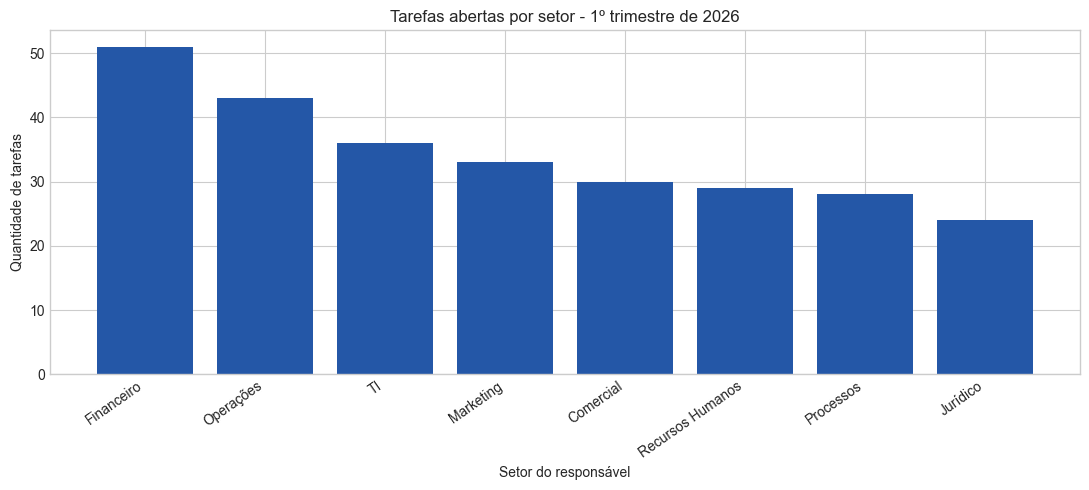


        **Interpretação:** o setor **Financeiro** apresentou o maior
        volume, com **51 tarefas**, equivalentes a
        **18.61%** das aberturas do trimestre.
        O volume indica carga recebida, mas não deve ser interpretado isoladamente como
        baixa eficiência; ele precisa ser comparado ao backlog e à quantidade de pessoas.
        

In [8]:
df_volume_setor = consultar(
    """
    SELECT
        s.nome_setor,
        COUNT(t.id_tarefa) AS total_tarefas,
        ROUND(
            100.0 * COUNT(t.id_tarefa)
            / SUM(COUNT(t.id_tarefa)) OVER (),
            2
        ) AS participacao_pct
    FROM tarefas t
    JOIN funcionarios f
      ON f.id_funcionario = t.id_responsavel
    JOIN setores s
      ON s.id_setor = f.id_setor
    WHERE date(t.data_abertura)
          BETWEEN date(:data_inicio) AND date(:data_fim)
    GROUP BY s.id_setor, s.nome_setor
    ORDER BY total_tarefas DESC
    """,
    PARAMETROS_PERIODO,
)

display(df_volume_setor)
salvar_tabela(df_volume_setor, "05_volume_tarefas_por_setor.csv")

plt.figure(figsize=(11, 5))
plt.bar(
    df_volume_setor["nome_setor"],
    df_volume_setor["total_tarefas"],
    color=CORES["azul"],
)
plt.title("Tarefas abertas por setor - 1º trimestre de 2026")
plt.xlabel("Setor do responsável")
plt.ylabel("Quantidade de tarefas")
plt.xticks(rotation=35, ha="right")
salvar_grafico("05_volume_tarefas_por_setor.png")

maior_volume = df_volume_setor.iloc[0]
display(
    Markdown(
        f"""
        **Interpretação:** o setor **{maior_volume['nome_setor']}** apresentou o maior
        volume, com **{int(maior_volume['total_tarefas'])} tarefas**, equivalentes a
        **{maior_volume['participacao_pct']:.2f}%** das aberturas do trimestre.
        O volume indica carga recebida, mas não deve ser interpretado isoladamente como
        baixa eficiência; ele precisa ser comparado ao backlog e à quantidade de pessoas.
        """
    )
)


### 7.2. Backlog por setor na data de corte


,nome_setor,tarefas_backlog,responsaveis_com_backlog,backlog_por_responsavel
0,Operações,89,7,12.71
1,Financeiro,84,8,10.50
2,Comercial,71,8,8.88
3,Processos,69,7,9.86
4,TI,65,7,9.29
5,Marketing,59,8,7.38
6,Recursos Humanos,57,8,7.13
7,Jurídico,37,7,5.29


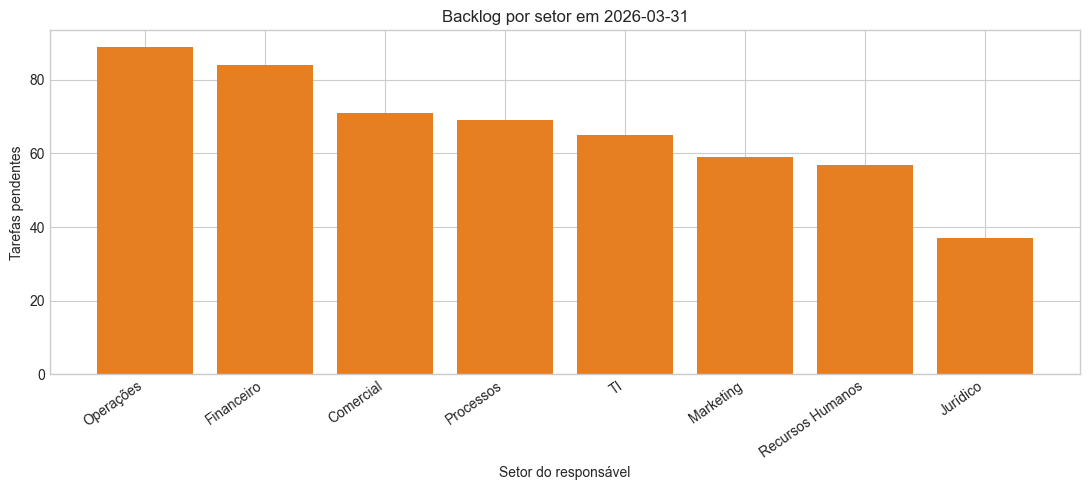


        **Interpretação:** em **31/03/2026**, o maior backlog estava no setor
        **Operações**, com
        **89 tarefas pendentes** e média de
        **12.71 pendências por responsável
        presente no backlog**. Esse resultado recomenda investigar capacidade,
        priorização e eventuais etapas de espera, sem concluir automaticamente que há
        baixo desempenho individual.
        

In [9]:
df_backlog = consultar(
    """
    SELECT
        s.nome_setor,
        COUNT(t.id_tarefa) AS tarefas_backlog,
        COUNT(DISTINCT f.id_funcionario) AS responsaveis_com_backlog,
        ROUND(
            1.0 * COUNT(t.id_tarefa)
            / COUNT(DISTINCT f.id_funcionario),
            2
        ) AS backlog_por_responsavel
    FROM tarefas t
    JOIN funcionarios f
      ON f.id_funcionario = t.id_responsavel
    JOIN setores s
      ON s.id_setor = f.id_setor
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    WHERE date(t.data_abertura) <= date(:data_fim)
      AND (
            t.data_conclusao IS NULL
            OR date(t.data_conclusao) > date(:data_fim)
          )
      AND st.nome_status <> 'Cancelada'
    GROUP BY s.id_setor, s.nome_setor
    ORDER BY tarefas_backlog DESC
    """,
    {"data_fim": DATA_FIM},
)

display(df_backlog)
salvar_tabela(df_backlog, "06_backlog_por_setor.csv")

plt.figure(figsize=(11, 5))
plt.bar(
    df_backlog["nome_setor"],
    df_backlog["tarefas_backlog"],
    color=CORES["laranja"],
)
plt.title(f"Backlog por setor em {DATA_FIM}")
plt.xlabel("Setor do responsável")
plt.ylabel("Tarefas pendentes")
plt.xticks(rotation=35, ha="right")
salvar_grafico("06_backlog_por_setor.png")

maior_backlog = df_backlog.iloc[0]
display(
    Markdown(
        f"""
        **Interpretação:** em **31/03/2026**, o maior backlog estava no setor
        **{maior_backlog['nome_setor']}**, com
        **{int(maior_backlog['tarefas_backlog'])} tarefas pendentes** e média de
        **{maior_backlog['backlog_por_responsavel']:.2f} pendências por responsável
        presente no backlog**. Esse resultado recomenda investigar capacidade,
        priorização e eventuais etapas de espera, sem concluir automaticamente que há
        baixo desempenho individual.
        """
    )
)


### 7.3. Taxa de atraso por setor


,nome_setor,tarefas_com_prazo_vencido_no_periodo,tarefas_atrasadas,taxa_atraso_pct
0,Operações,40,31,77.50
1,TI,32,23,71.88
2,Recursos Humanos,24,17,70.83
3,Financeiro,43,27,62.79
4,Comercial,27,16,59.26
5,Jurídico,21,11,52.38
6,Marketing,29,14,48.28
7,Processos,24,11,45.83


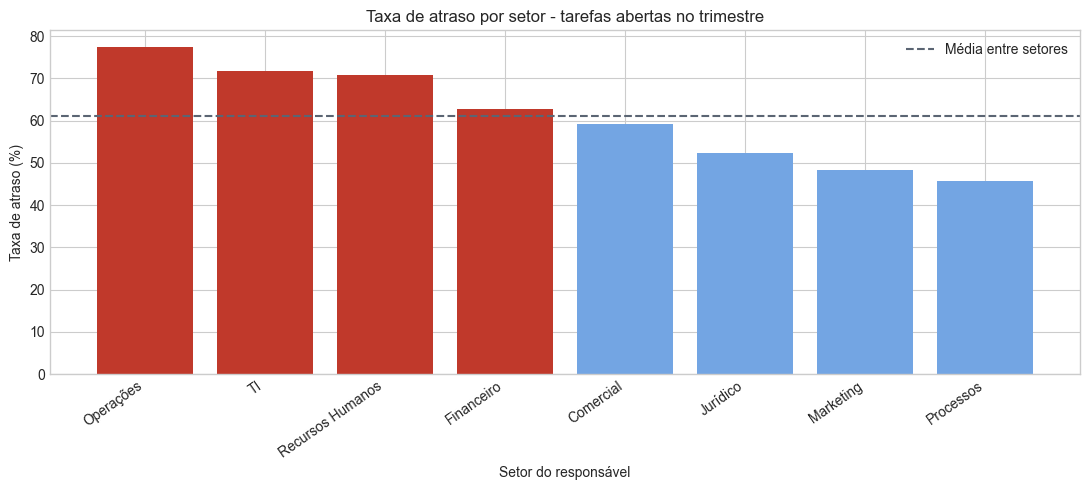


        **Interpretação:** o setor **Operações** apresentou a maior
        taxa de atraso, de **77.50%**, considerando
        tarefas não canceladas abertas no trimestre e com prazo até a data de corte.
        Recomenda-se detalhar esse resultado por processo e prioridade para verificar
        se os prazos são incompatíveis com a complexidade ou se existem esperas e
        aprovações que prolongam o fluxo.
        

In [10]:
df_atrasos = consultar(
    """
    SELECT
        s.nome_setor,
        COUNT(t.id_tarefa) AS tarefas_com_prazo_vencido_no_periodo,
        SUM(
            CASE
                WHEN t.data_conclusao IS NOT NULL
                 AND date(t.data_conclusao) > date(t.data_prazo)
                THEN 1
                WHEN t.data_conclusao IS NULL
                 AND date(t.data_prazo) < date(:data_fim)
                THEN 1
                ELSE 0
            END
        ) AS tarefas_atrasadas,
        ROUND(
            100.0 * SUM(
                CASE
                    WHEN t.data_conclusao IS NOT NULL
                     AND date(t.data_conclusao) > date(t.data_prazo)
                    THEN 1
                    WHEN t.data_conclusao IS NULL
                     AND date(t.data_prazo) < date(:data_fim)
                    THEN 1
                    ELSE 0
                END
            ) / COUNT(t.id_tarefa),
            2
        ) AS taxa_atraso_pct
    FROM tarefas t
    JOIN funcionarios f
      ON f.id_funcionario = t.id_responsavel
    JOIN setores s
      ON s.id_setor = f.id_setor
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    WHERE date(t.data_abertura)
          BETWEEN date(:data_inicio) AND date(:data_fim)
      AND date(t.data_prazo) <= date(:data_fim)
      AND st.nome_status <> 'Cancelada'
    GROUP BY s.id_setor, s.nome_setor
    ORDER BY taxa_atraso_pct DESC
    """,
    PARAMETROS_PERIODO,
)

display(df_atrasos)
salvar_tabela(df_atrasos, "07_taxa_atraso_por_setor.csv")

plt.figure(figsize=(11, 5))
cores_atraso = [
    CORES["vermelho"] if valor >= df_atrasos["taxa_atraso_pct"].mean()
    else CORES["azul_claro"]
    for valor in df_atrasos["taxa_atraso_pct"]
]
plt.bar(
    df_atrasos["nome_setor"],
    df_atrasos["taxa_atraso_pct"],
    color=cores_atraso,
)
plt.axhline(
    df_atrasos["taxa_atraso_pct"].mean(),
    color=CORES["cinza"],
    linestyle="--",
    label="Média entre setores",
)
plt.title("Taxa de atraso por setor - tarefas abertas no trimestre")
plt.xlabel("Setor do responsável")
plt.ylabel("Taxa de atraso (%)")
plt.xticks(rotation=35, ha="right")
plt.legend()
salvar_grafico("07_taxa_atraso_por_setor.png")

maior_atraso = df_atrasos.iloc[0]
display(
    Markdown(
        f"""
        **Interpretação:** o setor **{maior_atraso['nome_setor']}** apresentou a maior
        taxa de atraso, de **{maior_atraso['taxa_atraso_pct']:.2f}%**, considerando
        tarefas não canceladas abertas no trimestre e com prazo até a data de corte.
        Recomenda-se detalhar esse resultado por processo e prioridade para verificar
        se os prazos são incompatíveis com a complexidade ou se existem esperas e
        aprovações que prolongam o fluxo.
        """
    )
)


### 7.4. Tempo médio de execução por processo


,nome_processo,tarefas_concluidas,tempo_medio_dias,tempo_padrao_medio,desvio_medio_dias
0,Suporte de Sistemas,6,11.33,5.57,5.77
1,Recrutamento e Seleção,7,10.00,7.01,2.99
2,Controle de Demandas Operacionais,9,9.00,4.43,4.57
3,Atendimento Interno,11,8.91,3.90,5.01
4,Manutenção de Banco de Dados,7,8.43,3.97,4.46
5,Mapeamento de Processos,5,8.20,5.14,3.06
6,Contas a Pagar,5,7.80,6.86,0.94
7,Gestão de Documentos Jurídicos,10,7.70,9.23,-1.53
8,Padronização,8,7.25,9.45,-2.20
9,Automação de Rotinas,8,7.13,8.18,-1.05


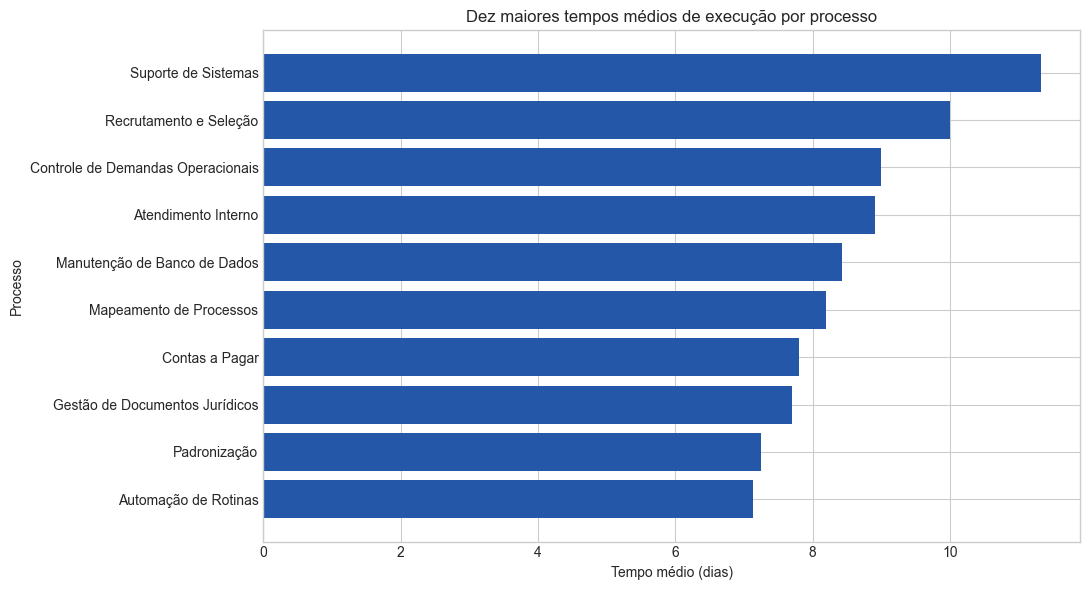


        **Interpretação:** o processo **Suporte de Sistemas**
        apresentou o maior tempo médio, com
        **11.33 dias**, calculado sobre
        **6 tarefas concluídas**.
        O desvio em relação ao tempo padrão médio foi de
        **5.77 dias**. O indicador sinaliza
        onde iniciar um estudo de fluxo, mas deve ser lido junto ao volume e à
        complexidade das atividades.
        

In [11]:
df_tempo_processo = consultar(
    """
    SELECT
        p.nome_processo,
        COUNT(t.id_tarefa) AS tarefas_concluidas,
        ROUND(
            AVG(
                julianday(t.data_conclusao)
                - julianday(t.data_inicio)
            ),
            2
        ) AS tempo_medio_dias,
        ROUND(AVG(a.tempo_padrao_estimado), 2) AS tempo_padrao_medio,
        ROUND(
            AVG(
                julianday(t.data_conclusao)
                - julianday(t.data_inicio)
                - a.tempo_padrao_estimado
            ),
            2
        ) AS desvio_medio_dias
    FROM tarefas t
    JOIN atividades a
      ON a.id_atividade = t.id_atividade
    JOIN processos p
      ON p.id_processo = a.id_processo
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    WHERE t.data_inicio IS NOT NULL
      AND t.data_conclusao IS NOT NULL
      AND date(t.data_conclusao)
          BETWEEN date(:data_inicio) AND date(:data_fim)
      AND st.nome_status <> 'Cancelada'
    GROUP BY p.id_processo, p.nome_processo
    ORDER BY tempo_medio_dias DESC
    """,
    PARAMETROS_PERIODO,
)

display(df_tempo_processo)
salvar_tabela(df_tempo_processo, "08_tempo_medio_por_processo.csv")

top_tempo = df_tempo_processo.head(10).sort_values("tempo_medio_dias")
plt.figure(figsize=(11, 6))
plt.barh(
    top_tempo["nome_processo"],
    top_tempo["tempo_medio_dias"],
    color=CORES["azul"],
)
plt.title("Dez maiores tempos médios de execução por processo")
plt.xlabel("Tempo médio (dias)")
plt.ylabel("Processo")
salvar_grafico("08_tempo_medio_por_processo.png")

processo_mais_lento = df_tempo_processo.iloc[0]
display(
    Markdown(
        f"""
        **Interpretação:** o processo **{processo_mais_lento['nome_processo']}**
        apresentou o maior tempo médio, com
        **{processo_mais_lento['tempo_medio_dias']:.2f} dias**, calculado sobre
        **{int(processo_mais_lento['tarefas_concluidas'])} tarefas concluídas**.
        O desvio em relação ao tempo padrão médio foi de
        **{processo_mais_lento['desvio_medio_dias']:.2f} dias**. O indicador sinaliza
        onde iniciar um estudo de fluxo, mas deve ser lido junto ao volume e à
        complexidade das atividades.
        """
    )
)


### 7.5. Produtividade por funcionário


,nome_funcionario,nome_setor,tarefas_concluidas,tempo_medio_execucao_dias
0,Igor Santana 28,Recursos Humanos,7,6.29
1,Gabriela Rocha 07,Financeiro,6,6.33
2,Fernanda Vieira 55,TI,5,6.80
3,João Batista 40,Operações,5,7.20
4,Bruno Almeida 02,Financeiro,5,8.20
5,Henrique Alves 38,Jurídico,5,8.20
6,Caio Mendes 22,Marketing,4,2.00
7,Ana Martins 01,Financeiro,4,5.00
8,Lucas Ferreira 42,Operações,4,7.25
9,Renata Cardoso 47,Processos,4,7.75


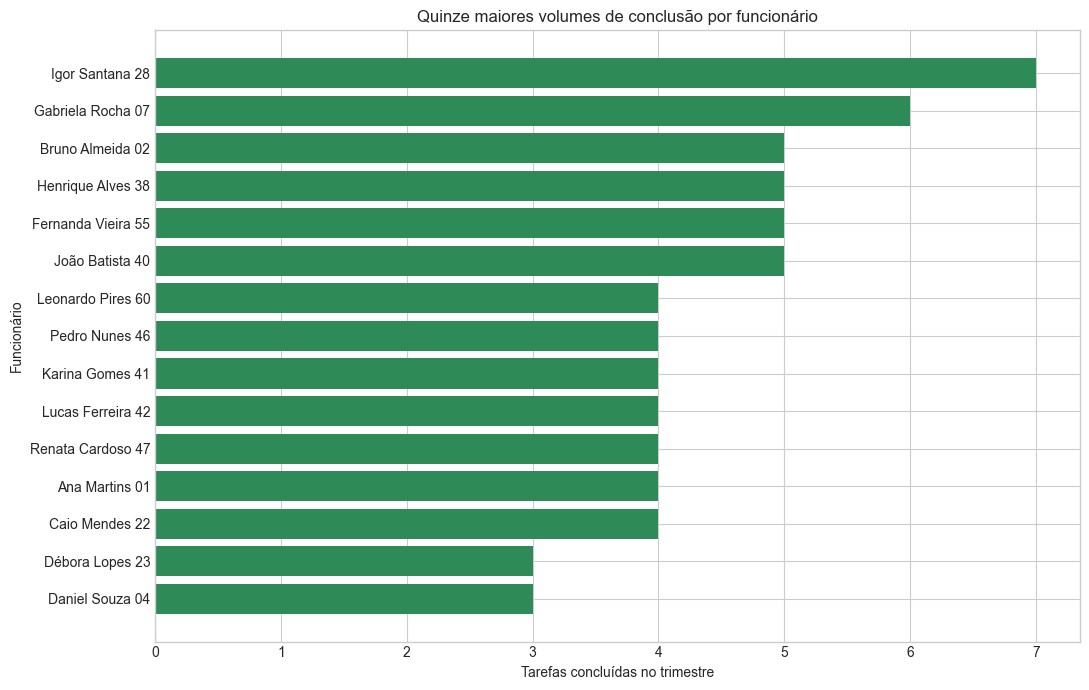


        **Interpretação:** **Igor Santana 28**, do setor
        **Recursos Humanos**, concluiu
        **7 tarefas** no trimestre.
        Esse ranking mede volume de entrega, não qualidade ou esforço. Comparações
        individuais exigem considerar complexidade, retrabalho, prioridade e
        distribuição das atividades.
        

In [12]:
df_produtividade = consultar(
    """
    SELECT
        f.nome_funcionario,
        s.nome_setor,
        COUNT(t.id_tarefa) AS tarefas_concluidas,
        ROUND(
            AVG(
                julianday(t.data_conclusao)
                - julianday(t.data_inicio)
            ),
            2
        ) AS tempo_medio_execucao_dias
    FROM tarefas t
    JOIN funcionarios f
      ON f.id_funcionario = t.id_responsavel
    JOIN setores s
      ON s.id_setor = f.id_setor
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    WHERE date(t.data_conclusao)
          BETWEEN date(:data_inicio) AND date(:data_fim)
      AND st.nome_status = 'Concluída'
    GROUP BY f.id_funcionario, f.nome_funcionario, s.nome_setor
    ORDER BY tarefas_concluidas DESC, tempo_medio_execucao_dias
    """,
    PARAMETROS_PERIODO,
)

display(df_produtividade.head(20))
salvar_tabela(df_produtividade, "09_produtividade_por_funcionario.csv")

top_produtividade = df_produtividade.head(15).sort_values("tarefas_concluidas")
plt.figure(figsize=(11, 7))
plt.barh(
    top_produtividade["nome_funcionario"],
    top_produtividade["tarefas_concluidas"],
    color=CORES["verde"],
)
plt.title("Quinze maiores volumes de conclusão por funcionário")
plt.xlabel("Tarefas concluídas no trimestre")
plt.ylabel("Funcionário")
salvar_grafico("09_produtividade_por_funcionario.png")

maior_produtividade = df_produtividade.iloc[0]
display(
    Markdown(
        f"""
        **Interpretação:** **{maior_produtividade['nome_funcionario']}**, do setor
        **{maior_produtividade['nome_setor']}**, concluiu
        **{int(maior_produtividade['tarefas_concluidas'])} tarefas** no trimestre.
        Esse ranking mede volume de entrega, não qualidade ou esforço. Comparações
        individuais exigem considerar complexidade, retrabalho, prioridade e
        distribuição das atividades.
        """
    )
)


### 7.6. Taxa de retrabalho por processo


,nome_processo,total_tarefas,tarefas_com_retrabalho,taxa_retrabalho_pct
0,Entrega de Serviços,14,7,50.00
1,Faturamento,8,3,37.50
2,Contas a Pagar,11,4,36.36
3,Atendimento Interno,12,4,33.33
4,Negociação Comercial,11,3,27.27
5,Automação de Rotinas,12,3,25.00
6,Gestão de Eventos,9,2,22.22
7,Conciliação Bancária,17,3,17.65
8,Qualificação de Leads,12,2,16.67
9,Gestão de Indicadores,6,1,16.67


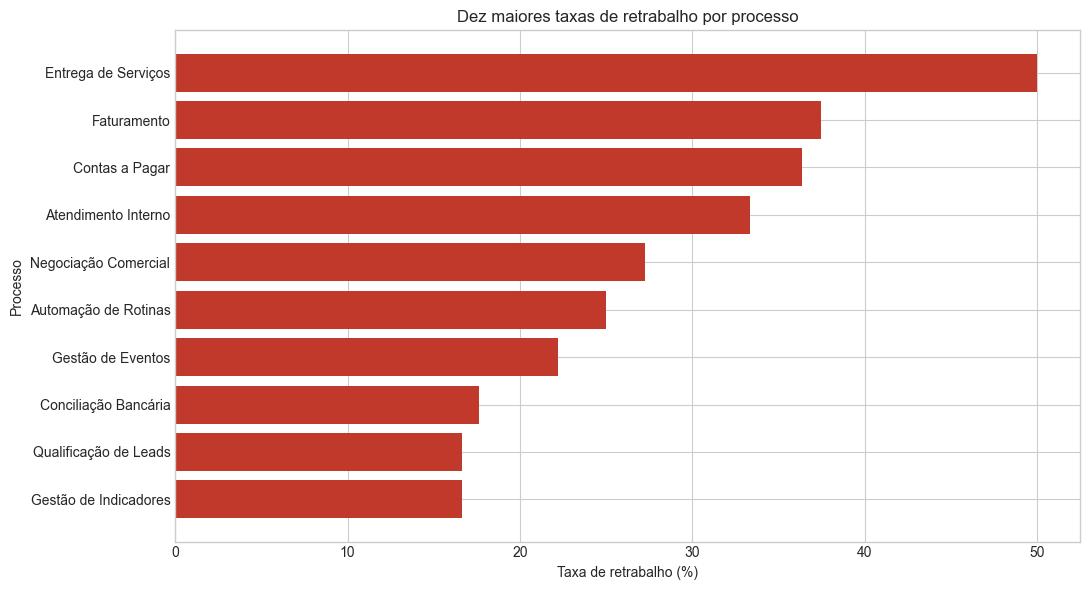


        **Interpretação:** o processo **Entrega de Serviços**
        apresentou a maior taxa de retrabalho:
        **50.00%**
        (7 de
        14 tarefas). É recomendável verificar
        critérios de entrada, instruções de trabalho, validações e causas de reabertura.
        

In [13]:
df_retrabalho = consultar(
    """
    SELECT
        p.nome_processo,
        COUNT(t.id_tarefa) AS total_tarefas,
        SUM(t.retrabalho) AS tarefas_com_retrabalho,
        ROUND(
            100.0 * SUM(t.retrabalho) / COUNT(t.id_tarefa),
            2
        ) AS taxa_retrabalho_pct
    FROM tarefas t
    JOIN atividades a
      ON a.id_atividade = t.id_atividade
    JOIN processos p
      ON p.id_processo = a.id_processo
    JOIN status_tarefa st
      ON st.id_status = t.id_status
    WHERE date(t.data_abertura)
          BETWEEN date(:data_inicio) AND date(:data_fim)
      AND st.nome_status <> 'Cancelada'
    GROUP BY p.id_processo, p.nome_processo
    ORDER BY taxa_retrabalho_pct DESC, total_tarefas DESC
    """,
    PARAMETROS_PERIODO,
)

display(df_retrabalho)
salvar_tabela(df_retrabalho, "10_taxa_retrabalho_por_processo.csv")

top_retrabalho = df_retrabalho.head(10).sort_values("taxa_retrabalho_pct")
plt.figure(figsize=(11, 6))
plt.barh(
    top_retrabalho["nome_processo"],
    top_retrabalho["taxa_retrabalho_pct"],
    color=CORES["vermelho"],
)
plt.title("Dez maiores taxas de retrabalho por processo")
plt.xlabel("Taxa de retrabalho (%)")
plt.ylabel("Processo")
salvar_grafico("10_taxa_retrabalho_por_processo.png")

maior_retrabalho = df_retrabalho.iloc[0]
display(
    Markdown(
        f"""
        **Interpretação:** o processo **{maior_retrabalho['nome_processo']}**
        apresentou a maior taxa de retrabalho:
        **{maior_retrabalho['taxa_retrabalho_pct']:.2f}%**
        ({int(maior_retrabalho['tarefas_com_retrabalho'])} de
        {int(maior_retrabalho['total_tarefas'])} tarefas). É recomendável verificar
        critérios de entrada, instruções de trabalho, validações e causas de reabertura.
        """
    )
)


### 7.7. Evolução mensal das aberturas e conclusões


,mes,tarefas_abertas,tarefas_concluidas,saldo_fluxo
0,2026-01,108,60,-48
1,2026-02,74,43,-31
2,2026-03,92,56,-36


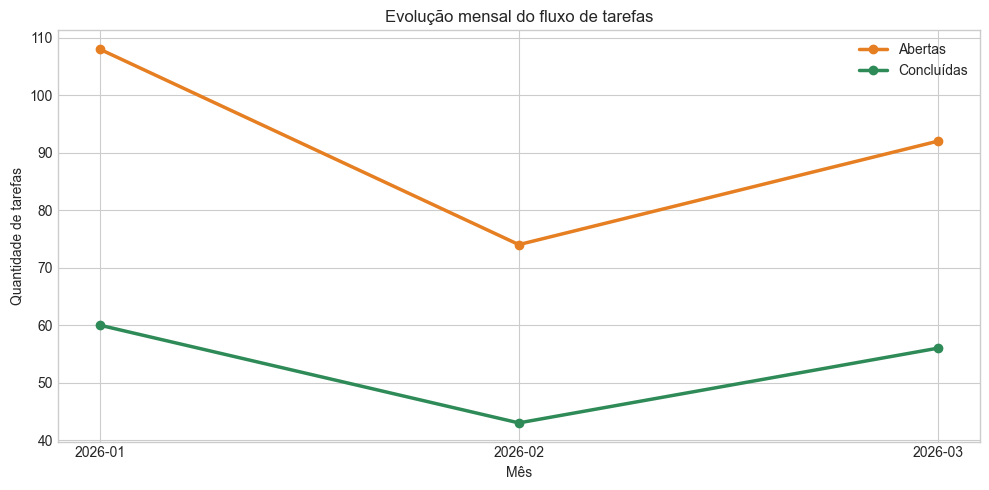


        **Interpretação:** o saldo agregado do trimestre foi de
        **-115 tarefas**, indicando mais aberturas do que conclusões. Esse saldo ajuda a
        avaliar se o fluxo de saída acompanhou a entrada de novas demandas, mas não
        substitui a fotografia completa do backlog, que também contém pendências
        provenientes de meses anteriores.
        

In [14]:
df_evolucao = consultar(
    """
    WITH RECURSIVE meses(mes) AS (
        SELECT substr(:data_inicio, 1, 7)
        UNION ALL
        SELECT strftime('%Y-%m', date(mes || '-01', '+1 month'))
        FROM meses
        WHERE mes < substr(:data_fim, 1, 7)
    ),
    aberturas AS (
        SELECT substr(data_abertura, 1, 7) AS mes, COUNT(*) AS abertas
        FROM tarefas
        WHERE date(data_abertura)
              BETWEEN date(:data_inicio) AND date(:data_fim)
        GROUP BY substr(data_abertura, 1, 7)
    ),
    conclusoes AS (
        SELECT substr(data_conclusao, 1, 7) AS mes, COUNT(*) AS concluidas
        FROM tarefas t
        JOIN status_tarefa st
          ON st.id_status = t.id_status
        WHERE date(data_conclusao)
              BETWEEN date(:data_inicio) AND date(:data_fim)
          AND st.nome_status = 'Concluída'
        GROUP BY substr(data_conclusao, 1, 7)
    )
    SELECT
        meses.mes,
        COALESCE(aberturas.abertas, 0) AS tarefas_abertas,
        COALESCE(conclusoes.concluidas, 0) AS tarefas_concluidas,
        COALESCE(conclusoes.concluidas, 0)
        - COALESCE(aberturas.abertas, 0) AS saldo_fluxo
    FROM meses
    LEFT JOIN aberturas ON aberturas.mes = meses.mes
    LEFT JOIN conclusoes ON conclusoes.mes = meses.mes
    ORDER BY meses.mes
    """,
    PARAMETROS_PERIODO,
)

display(df_evolucao)
salvar_tabela(df_evolucao, "11_evolucao_mensal.csv")

plt.figure(figsize=(10, 5))
plt.plot(
    df_evolucao["mes"],
    df_evolucao["tarefas_abertas"],
    marker="o",
    linewidth=2.5,
    color=CORES["laranja"],
    label="Abertas",
)
plt.plot(
    df_evolucao["mes"],
    df_evolucao["tarefas_concluidas"],
    marker="o",
    linewidth=2.5,
    color=CORES["verde"],
    label="Concluídas",
)
plt.title("Evolução mensal do fluxo de tarefas")
plt.xlabel("Mês")
plt.ylabel("Quantidade de tarefas")
plt.legend()
salvar_grafico("11_evolucao_mensal.png")

saldo_trimestre = int(df_evolucao["saldo_fluxo"].sum())
sentido = "mais conclusões do que aberturas" if saldo_trimestre > 0 else "mais aberturas do que conclusões"
display(
    Markdown(
        f"""
        **Interpretação:** o saldo agregado do trimestre foi de
        **{saldo_trimestre:+d} tarefas**, indicando {sentido}. Esse saldo ajuda a
        avaliar se o fluxo de saída acompanhou a entrada de novas demandas, mas não
        substitui a fotografia completa do backlog, que também contém pendências
        provenientes de meses anteriores.
        """
    )
)


## 8. Painel-resumo dos indicadores

Consolidação dos principais resultados.


,indicador,resultado,unidade
0,Tarefas abertas no trimestre,274.00,tarefas
1,Tarefas concluídas no trimestre,159.00,tarefas
2,Backlog em 31/03/2026,531.00,tarefas
3,Taxa geral de atraso,62.50,%
4,Tempo médio de execução,6.92,dias
5,Taxa geral de retrabalho,16.79,%


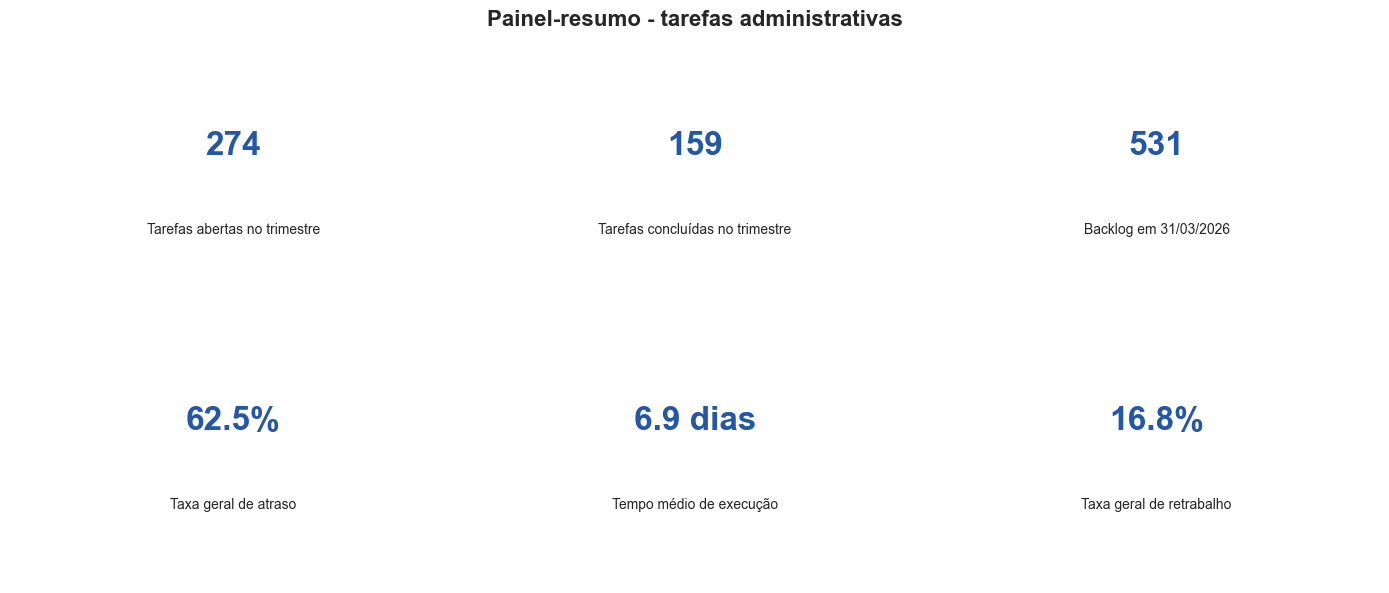

WindowsPath('c:/Users/gusta/OneDrive/Área de Trabalho/Práticas em Eng Prod/resultados_n2/12_painel_resumo.png')

In [15]:
resumo_periodo = consultar(
    """
    SELECT
        COUNT(*) AS tarefas_abertas_periodo,
        SUM(CASE WHEN retrabalho = 1 THEN 1 ELSE 0 END) AS retrabalhos_periodo
    FROM tarefas t
    JOIN status_tarefa st ON st.id_status = t.id_status
    WHERE date(data_abertura)
          BETWEEN date(:data_inicio) AND date(:data_fim)
      AND st.nome_status <> 'Cancelada'
    """,
    PARAMETROS_PERIODO,
)

total_abertas = int(df_volume_setor["total_tarefas"].sum())
total_concluidas = int(df_evolucao["tarefas_concluidas"].sum())
total_backlog = int(df_backlog["tarefas_backlog"].sum())
total_atrasaveis = int(df_atrasos["tarefas_com_prazo_vencido_no_periodo"].sum())
total_atrasadas = int(df_atrasos["tarefas_atrasadas"].sum())
taxa_atraso_geral = (
    100.0 * total_atrasadas / total_atrasaveis
    if total_atrasaveis
    else 0.0
)
tempo_medio_ponderado = (
    (
        df_tempo_processo["tempo_medio_dias"]
        * df_tempo_processo["tarefas_concluidas"]
    ).sum()
    / df_tempo_processo["tarefas_concluidas"].sum()
)
tarefas_validas_retrabalho = int(resumo_periodo.loc[0, "tarefas_abertas_periodo"])
retrabalhos = int(resumo_periodo.loc[0, "retrabalhos_periodo"])
taxa_retrabalho_geral = (
    100.0 * retrabalhos / tarefas_validas_retrabalho
    if tarefas_validas_retrabalho
    else 0.0
)

df_painel = pd.DataFrame(
    [
        ["Tarefas abertas no trimestre", total_abertas, "tarefas"],
        ["Tarefas concluídas no trimestre", total_concluidas, "tarefas"],
        ["Backlog em 31/03/2026", total_backlog, "tarefas"],
        ["Taxa geral de atraso", taxa_atraso_geral, "%"],
        ["Tempo médio de execução", tempo_medio_ponderado, "dias"],
        ["Taxa geral de retrabalho", taxa_retrabalho_geral, "%"],
    ],
    columns=["indicador", "resultado", "unidade"],
)

display(df_painel)
salvar_tabela(df_painel, "12_painel_resumo.csv")

fig, eixos = plt.subplots(2, 3, figsize=(14, 6))
eixos = eixos.flatten()

for eixo, linha in zip(eixos, df_painel.itertuples(index=False)):
    eixo.axis("off")
    if linha.unidade == "%":
        valor_formatado = f"{linha.resultado:.1f}%"
    elif linha.unidade == "dias":
        valor_formatado = f"{linha.resultado:.1f} dias"
    else:
        valor_formatado = f"{int(linha.resultado)}"

    eixo.text(
        0.5,
        0.62,
        valor_formatado,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        color=CORES["azul"],
    )
    eixo.text(
        0.5,
        0.30,
        linha.indicador,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True,
    )

fig.suptitle(
    "Painel-resumo - tarefas administrativas",
    fontsize=16,
    fontweight="bold",
)
salvar_grafico("12_painel_resumo.png")


## 9. Recomendações e plano inicial de ação

As recomendações abaixo transformam dados em possíveis decisões. Elas não afirmam que
os indicadores, isoladamente, comprovam uma causa. Antes da implementação, é necessário
validar os achados com os responsáveis pelos processos.


In [16]:
df_plano_acao = pd.DataFrame(
    [
        {
            "prioridade": "Alta",
            "problema_identificado": "Backlog elevado",
            "evidencia": (
                f"{maior_backlog['nome_setor']}: "
                f"{int(maior_backlog['tarefas_backlog'])} pendências"
            ),
            "acao_recomendada": (
                "Revisar a fila, classificar urgência e redistribuir demandas "
                "após avaliar a capacidade disponível."
            ),
            "responsavel_sugerido": "Gestor do setor e equipe de Processos",
        },
        {
            "prioridade": "Alta",
            "problema_identificado": "Atrasos recorrentes",
            "evidencia": (
                f"{maior_atraso['nome_setor']}: "
                f"{maior_atraso['taxa_atraso_pct']:.2f}% de atraso"
            ),
            "acao_recomendada": (
                "Estratificar atrasos por processo e prioridade; revisar prazos, "
                "aprovações e tempos de espera."
            ),
            "responsavel_sugerido": "Gestor do setor e equipe de Processos",
        },
        {
            "prioridade": "Média",
            "problema_identificado": "Retrabalho elevado",
            "evidencia": (
                f"{maior_retrabalho['nome_processo']}: "
                f"{maior_retrabalho['taxa_retrabalho_pct']:.2f}%"
            ),
            "acao_recomendada": (
                "Aplicar análise de causa, revisar instruções e criar checklist "
                "de qualidade antes da conclusão."
            ),
            "responsavel_sugerido": "Dono do processo e equipe executora",
        },
        {
            "prioridade": "Média",
            "problema_identificado": "Tempo de execução elevado",
            "evidencia": (
                f"{processo_mais_lento['nome_processo']}: "
                f"{processo_mais_lento['tempo_medio_dias']:.2f} dias"
            ),
            "acao_recomendada": (
                "Mapear o fluxo atual, identificar esperas e comparar o tempo "
                "real com o padrão por atividade."
            ),
            "responsavel_sugerido": "Equipe de Processos",
        },
        {
            "prioridade": "Baixa",
            "problema_identificado": "Acompanhamento pouco frequente",
            "evidencia": "Indicadores dependem de análise pontual",
            "acao_recomendada": (
                "Atualizar mensalmente o painel de volume, backlog, atraso, "
                "lead time e retrabalho."
            ),
            "responsavel_sugerido": "Processos e TI",
        },
    ]
)

display(df_plano_acao)
salvar_tabela(df_plano_acao, "13_plano_inicial_acao.csv")


,prioridade,problema_identificado,evidencia,acao_recomendada,responsavel_sugerido
0,Alta,Backlog elevado,Operações: 89 pendências,"Revisar a fila, classificar urgência e redistr...",Gestor do setor e equipe de Processos
1,Alta,Atrasos recorrentes,Operações: 77.50% de atraso,Estratificar atrasos por processo e prioridade...,Gestor do setor e equipe de Processos
2,Média,Retrabalho elevado,Entrega de Serviços: 50.00%,"Aplicar análise de causa, revisar instruções e...",Dono do processo e equipe executora
3,Média,Tempo de execução elevado,Suporte de Sistemas: 11.33 dias,"Mapear o fluxo atual, identificar esperas e co...",Equipe de Processos
4,Baixa,Acompanhamento pouco frequente,Indicadores dependem de análise pontual,"Atualizar mensalmente o painel de volume, back...",Processos e TI


WindowsPath('c:/Users/gusta/OneDrive/Área de Trabalho/Práticas em Eng Prod/resultados_n2/13_plano_inicial_acao.csv')

## 10. Resumo sobre a extração

A aplicação demonstrou que o banco relacional permite integrar informações antes
distribuídas entre setores, funcionários, processos, atividades e tarefas. As consultas
com `JOIN`, agregações e filtros temporais converteram registros operacionais em
indicadores de carga, fluxo, prazo, produtividade e qualidade.

Os maiores valores de um indicador devem ser tratados como **sinais para investigação**,
não como prova isolada de ineficiência. Um setor pode possuir grande volume por ser
naturalmente mais demandado; um processo pode apresentar maior tempo por ser mais
complexo; e um funcionário pode concluir menos tarefas porque executa atividades mais
longas. Por isso, a decisão gerencial deve combinar os indicadores e validar o contexto
com as equipes envolvidas.

Como limitações, o histórico não registra explicitamente a data de
cancelamento e o campo de retrabalho é binário e não informa a causa. Em uma
aplicação empresarial futura, recomenda-se acrescentar motivo do retrabalho, duração das
etapas, registros de espera e metas por processo.


## 11. Encerramento da conexão e conferência dos arquivos gerados


In [17]:
conexao.close()

arquivos_gerados = sorted(
    caminho.name
    for caminho in PASTA_RESULTADOS.iterdir()
    if caminho.is_file()
)

print("Conexão encerrada com segurança.")
print(f"{len(arquivos_gerados)} arquivos foram gerados em:")
print(PASTA_RESULTADOS.resolve())

for arquivo in arquivos_gerados:
    print(f"- {arquivo}")


Conexão encerrada com segurança.
21 arquivos foram gerados em:
C:\Users\gusta\OneDrive\Área de Trabalho\Práticas em Eng Prod\resultados_n2
- 01_resumo_tabelas.csv
- 02_modelo_relacional.png
- 03_distribuicoes_status_prioridade.png
- 04_base_analitica_tarefas_periodo.csv
- 05_volume_tarefas_por_setor.csv
- 05_volume_tarefas_por_setor.png
- 06_backlog_por_setor.csv
- 06_backlog_por_setor.png
- 07_taxa_atraso_por_setor.csv
- 07_taxa_atraso_por_setor.png
- 08_tempo_medio_por_processo.csv
- 08_tempo_medio_por_processo.png
- 09_produtividade_por_funcionario.csv
- 09_produtividade_por_funcionario.png
- 10_taxa_retrabalho_por_processo.csv
- 10_taxa_retrabalho_por_processo.png
- 11_evolucao_mensal.csv
- 11_evolucao_mensal.png
- 12_painel_resumo.csv
- 12_painel_resumo.png
- 13_plano_inicial_acao.csv
